# **LAB 1: LINEAR REGRESSION**

**Name:** Shishir Pandeya (ACE079BCT062)

## Background

- **Linear Regression**: A supervised learning method that predicts continuous values by fitting a straight line (or plane) to the data.

- **Simple Linear Regression**: Uses one feature to predict the target. Easy to interpret but too basic for complex data. ($y = wx + b$)

- **Multiple Linear Regression**: Uses multiple features to predict the target, creating a multidimensional plane for more accurate predictions. ($y = w_1x_1 + w_2x_2 + ... + b$)

- **Mean Squared Error (MSE)**: Measures how far predictions are from actual values. Squaring emphasizes larger mistakes.

- **Gradient Descent**: Optimization method that updates model weights step by step to minimize error until the best fit is found.

# **Task 1: Simple Linear Regression (Single Feature)**
We build a simple linear regression model with only one input feature i.e. housing_median_age

In [1]:
# dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Retrieval and Collection
We will now load the California Housing Dataset.

In [2]:
try:
    df = pd.read_csv('housing.csv')
except FileNotFoundError:
    print("File not found. Please upload 'housing.csv' to your notebook environment.")

Displaying basic information shape and column names

In [3]:
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns}')
df.head()

Shape: (20640, 10)
Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Data Cleaning
We now check the data whether it contains missing values or not and handle it if any missing values is found.

In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

207 rows contains missing data for total_bedrooms column. We now create a new colomn 'total_bedroom_missing' to indicate the missing data. 0 for presence of data and 1 for missing data. We created this as an indicator that data was missing in this row before filling the original missing data with real value(we are gonna fill the missing rows with median values)

In [5]:
# Create new column for determing where data is missing.
df['total_bedrooms_missing'] = df['total_bedrooms'].isnull().astype(int)

df['total_bedrooms_missing'].value_counts()


total_bedrooms_missing
0    20433
1      207
Name: count, dtype: int64

We now replace the missing values (NaN) in total_bedrooms column with the median value of that column.

In [6]:
# Replace the original 'total_bedrooms' column with new 'total_bedrooms' column by filling missing values with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Now validate whether data contains missing values or not.
df.isnull().sum()

longitude                 0
latitude                  0
housing_median_age        0
total_rooms               0
total_bedrooms            0
population                0
households                0
median_income             0
median_house_value        0
ocean_proximity           0
total_bedrooms_missing    0
dtype: int64

Therefore, we handled the missing values by adding median value of that column where value was missing.

## Feature Design

In this step, we select a single feature (i.e. housing_median_age) as input

In [7]:
# Input feature. X is 2D because sklearn expects a 2D array for features.
X = df[['housing_median_age']]  

# Target variable
y = df['median_house_value']

We chose 'housing_median_age' as the input feature because it is numeric, has no missing value and shows a good correlation with the target value 'median_house_value'

## 4. Algorithm Selection

We choose Linear Regression for this task. Linear regression is appropriate for this task because the target variable 'median_house_value' is continuous and numeric, which matches the model’s prediction capability. The input feature 'housing_median_age', is also numeric, allowing the model to directly estimate the relationship without additional preprocessing. Linear regression assumes a linear relationship between input and output, which is reasonable for this feature.

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

## 5. Loss Function Selection

We use Mean Squared Error (MSE).
MSE is a loss function metric that is used to measuer how far model predictions are from actual values in linear regression to determine accuracy of the model.

The Mean Squared Error is:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

## 6. Model Learning (Training)

We first split the data into 80% for training and 20% for testing as we don't train and test the model on same dataset.

In [10]:
from sklearn.model_selection import train_test_split


# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    shuffle=True, 
    random_state=42
)

model.fit(X_train, y_train)

# Produces prediction on new unseen testing data
pred_y = model.predict(X_test)

print(f"Learned Bias (Intercept): {model.intercept_}")
print(f"Learned Weights (Coefficients): {model.coef_}")

Learned Bias (Intercept): 179975.00158647486
Learned Weights (Coefficients): [951.46186715]


What happens here is :

1. Linear Regression computes the best-fit line using the equation: 
$$
\hat{y} = \text{intercept} + (\text{slope} \times X)
$$

2. The slope and intercept are calculated to minimize MSE on training data.

## 7. Model Evaluation

We evaluate our model on Mean Squared Error (MSE) metric.

In [11]:
mse = np.round(mean_squared_error(y_test, pred_y), 2)
print(f'mean squared error is {mse}')

print("The R² score of the model is", np.round(r2_score(y_test,pred_y), 2))

mean squared error is 12939617265.1
The R² score of the model is 0.01


## Visualizing the Regression Line

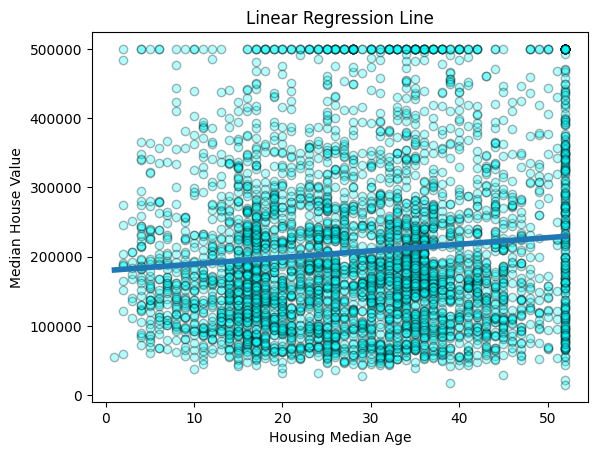

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

# scatter actual data
plt.scatter(X_test, y_test, color='cyan', edgecolors='black', alpha=0.3)

# sort values for smooth line . Flatten converts array into 1D.
sorted_index = np.argsort(X_test.values.flatten())
plt.plot(
    X_test.values.flatten()[sorted_index],
    pred_y[sorted_index],
    linewidth=4
)

plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.title("Linear Regression Line")
plt.show()


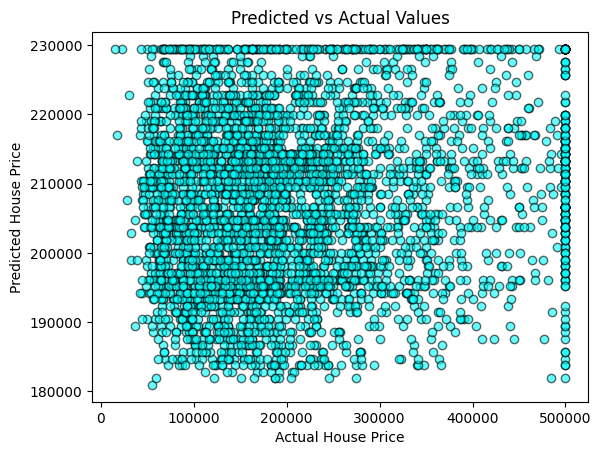

In [13]:
plt.figure()

# plt.scatter(y_test, pred_y, alpha=0.3)
plt.scatter(y_test, pred_y, color='cyan', edgecolor='black', alpha=0.6)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Predicted vs Actual Values")

plt.show()


## Interpretation

Mean Squared Error: 12939617265.1
Root Mean Squared Error (RMSE): √12,939,617,265.1 : 113,743
R² Score: 0.01

Here, the RMSE tell us, on average, how far the model's prediction are from the actual house prices. Here, RMSE of 1,13,743 means the predicted price of the house is off roughly $113743 on average.

The lower score of R² i.e. 1% states that only 1% variation in house prices is explained by the model and the single-feature model is not accurate for real world predictions.

## Conclusion: 
In our graph, the line is almost flat, which tells us that only age cannot be used to predict the price of the house. Therefore, the model underfits the data, meaning only the single feature 'housing_median_age' cannot be used to accurtely predict 'median_house_value'.

# ---------------------------------------------------------
# **Task 2: Linear Regression with Multiple Features**


## 1 & 2. Data Retrieval and Cleaning
We reuse the cleaned dataset from Task 1.
Data is loaded, missing values checked, and affected rows are removed.

## 3. Feature Design (All Features)
Here, we select all columns except the label 'median_house_value'.

Since the dataset contains the ocean_proximity column, which is an object (categorical) data type, we must convert it into a numerical format using One Hot Encoding, which creates individual binary columns (0 or 1) for each category, such as "Inland" or "Near Bay," thata allows the model to mathematically process location data without implying a numerical ranking. We also apply Feature Scaling using StandardScaler to normalize the data. This is necessary because features like population (measured in thousands) and median_income  have vastly different ranges; scaling ensures the model does not become biased toward features with larger numerical values

In [14]:
# --- STEP 3: FEATURE DESIGN ---

# 1. Feature Selection & Handle Categorical Data
# Convert 'ocean_proximity' into numerical columns
df_final = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 2. Drop 'total_bedrooms_missing' column
if 'total_bedrooms_missing' in df_final.columns:
    df_final = df_final.drop('total_bedrooms_missing', axis=1)

# 3. Defining X (Input Features) and y (Target Label)
X = df_final.drop('median_house_value', axis=1)  # Everything except the price
y = df_final['median_house_value']               # Just the price

# 4. Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame to keep column names
X_final = pd.DataFrame(X_scaled, columns=X.columns)

# Verification
print("Features used in Task 2 (excluding 'total_bedrooms_missing'):")
print(X_final.columns.tolist())
print(f"\nTotal number of features: {X_final.shape[1]}")


Features used in Task 2 (excluding 'total_bedrooms_missing'):
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

Total number of features: 12


## 4, 5, & 6. Model Selection, Loss, and Training
We repeat the training pipeline using the new, scaled multiple features dataset.
* Algorithm: Linear Regression
* Loss function: MSE

In [15]:
# 4 Model Selection
from sklearn.linear_model import LinearRegression
model_m = LinearRegression()

# 5 Loss Function
from sklearn.metrics import mean_squared_error, r2_score

# 6 Model Training
# We split the data (80% train, 20% test) and fit the model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
model_m.fit(X_train, y_train)

#prediction evaluation
y_pred = model_m.predict(X_test)

# The bias and weights learned by the model
print(f"Learned Bias (Intercept): {model_m.intercept_}")
print(f"Learned Weights (Coefficients): {model_m.coef_}")

Learned Bias (Intercept): 206645.58580614193
Learned Weights (Coefficients): [-53770.0294899  -54397.86979448  13871.2778323  -13136.29036175
  43107.99324277 -43228.32336955  18448.01613063  74991.69860632
 -18519.17484728   2118.43757154  -1613.26383932   1149.27838844]


## 7. Model Evaluation (Task 2)
We evaluate the multi-feature model using the same metrics. We can expect higher accuracy and recall because the model can now look at multiple parameters.


In [16]:
# MODEL EVLUATION

# Calculating the performance metrics
mse_m = mean_squared_error(y_test, y_pred)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test, y_pred)

# Printing the Performance Summary
print(f"Task 2 Performance Metrics:")
print(f"Mean Squared Error: {mse_m:.2f}")
print(f"Root Mean Squared Error: ${rmse_m:,.2f}")
print(f"R² Score: {r2_m:.4f}")
print("-" * 30)

# Displaying the Intercept and Coefficients
print(f"Model Intercept: {model_m.intercept_:,.2f}")
print("Feature Coefficients:")
coeffs = pd.DataFrame({'Feature': X_final.columns, 'Weight': model_m.coef_})
print(coeffs.sort_values(by='Weight', ascending=False))

Task 2 Performance Metrics:
Mean Squared Error: 4908476721.16
Root Mean Squared Error: $70,060.52
R² Score: 0.6254
------------------------------
Model Intercept: 206,645.59
Feature Coefficients:
                       Feature        Weight
7                median_income  74991.698606
4               total_bedrooms  43107.993243
6                   households  18448.016131
2           housing_median_age  13871.277832
9       ocean_proximity_ISLAND   2118.437572
11  ocean_proximity_NEAR OCEAN   1149.278388
10    ocean_proximity_NEAR BAY  -1613.263839
3                  total_rooms -13136.290362
8       ocean_proximity_INLAND -18519.174847
5                   population -43228.323370
0                    longitude -53770.029490
1                     latitude -54397.869794


### Observation and Interpretation (Task 2)
- Mean Squared Error: 4908476721.16
- Root Mean Squared Error: 70,060.52
- $R^2$ Score: 0.6254

The model demonstrates a stronger performance with an RMSE of 70,060.52 and an R² Score of 0.6254.
This indicates that the model is able to explain nearly 62% of the differences in housing prices in California by analyzing all 12 factos simultaneously.



* Interpretation of weights:

The model shows that Median Income is the biggest factor, where a typical increase in neighborhood wealth adds about 74,991.698606 to the price. This confirms that local economy is the main driver of California housing costs. Geography is also huge: the negative weights for Longitude and Latitude (around 54k) and the Inland status (-18,519.174847) show the price drop when moving away from the coast or major hubs.

Interestingly, the model found that total bedrooms add a lot of value (+43,107.993243) while total rooms actually have a small negative impact. This suggests that the model cares more about how many people a house can hold rather than just having a lot of extra, undefined space.

### Conclusion: 
Using a multiple feature approach allows the model to capture the complex relationship between wealth, location, and home size to produce much more reliable price estimates.

# ---------------------------------------------------------
# **Model Comparison & Conclusion**

### 1. Which model performs better and why?
The Task 2 model (using all features) performs much better than the single-feature Task 1 model.

Task 1 (Housing Age only): RMSE = 113,743

Task 2 (All Features): RMSE = 70,060.52

Why: House prices are influenced by many factors such as income, number of rooms, population, and proximity to the ocean. Housing age alone cannot capture these complexities. By including multiple features, the model can account for the different aspects that determine a house’s value, making predictions more accurate and realistic.

### 2. Why does using multiple features help or hurt performance?
Using multiple features significantly improved the model’s performance compared to using only housing age. In Task 1, the model had an RMSE of about $113,743 and an R² score of 0.01, showing that housing age alone could not explain house prices well. After adding multiple features in Task 2, the RMSE decreased to about $70,060.52, meaning the average prediction error became much smaller. The R² score also increased to around 0.6254, indicating that the model could now explain about 62% of the variation in house prices. This improvement shows that house prices depend on multiple factors, and including more relevant features allows the model to better capture real-world relationships and make more accurate predictions.

### 3. Which model is easier to interpret?
Task 1 is easier to interpret because it uses only a single feature and is defined by just one coefficient and an intercept. This makes it simple to understand and visualize as a straight line on a 2D graph. However, although it is easy to explain, the model is too basic and not very accurate because it ignores important factors like income, location, and housing characteristics. In contrast, Task 2 is more complex because it uses many features, making it harder to visualize and interpret directly. Despite this complexity, it provides more meaningful insights and much better accuracy, as the model considers multiple real-world factors that influence house prices.

### 4. Final Conclusion
Using only one feature was not enough to capture the complex factors that influence housing prices in the California housing market. When multiple features such as income, location, and housing characteristics were included, the model’s performance improved significantly, reaching an R² score of around 62% and reducing prediction error. This shows that real-world problems like house price prediction require multiple relevant features to better represent how different factors interact and affect the final outcome.